# Large-Scale Thematic Research Workflow (Client Example)

Client-ready workflow on [Bigdata.com](https://bigdata.com) to build auditable thematic signals from unstructured content across a broad equity universe.

This notebook supports two signal families with an explicit accuracy and recall trade-off:

1. **Basic signal (high recall, lower precision, fast)**
2. **Advanced signal (higher precision, slower, with LLM validation)**



**Create a `.env` file in this folder before running the notebook**

Required:

`BIGDATA_API_KEY=your_api_key`

Optional:

- `BIGDATA_API_BASE_URL=...` (override API endpoint)
- `OPENAI_API_KEY=...` (needed for LLM validation stage)

Notes:
- Restart the kernel after changing credentials.
- Keep credentials out of source control.

Install the requirements if you have not done it.


In [23]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Imports



In [24]:
import asyncio
import json
import logging
import os
import pickle
import sys
from pathlib import Path
from zoneinfo import ZoneInfo

import nest_asyncio
import pandas as pd
import plotly.io as pio
from dotenv import load_dotenv

from src import (
    BigDataSession,
    aggregate_results_by_chunk,
    extract_companies_from_entity_list,
    get_unknown_entities_from_df_column,
    keep_only_companies_in_detections,
    map_create_only_companies_column,
    explode_to_dataframe,
)

from bigdata_smart_batching import (plan_search, 
save_plan, execute_search, 
deduplicate_documents, load_plan, convert_to_dataframe

)
import importlib
import src.helper as helper_mod

importlib.reload(helper_mod)
build_rolling_impact_signal = helper_mod.build_rolling_impact_signal
plot_top_entities_rolling_signal = helper_mod.plot_top_entities_rolling_signal
mask_companies_in_df = helper_mod.mask_companies_in_df

from src.labeler.screener_labeler import Labeler, merge_validation_labels

from src.mindmap import generate_risk_tree, generate_theme_tree


## Configuration



In [25]:
# Suppress verbose HTTP logging
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

# Load environment variables
env_path = Path.cwd() / ".env"
if env_path.exists():
    load_dotenv(env_path)

# Add current directory to path for local imports
sys.path.insert(0, str(Path.cwd()))

# Apply nest_asyncio if needed (for Jupyter environments)
try:
    asyncio.get_running_loop()
    nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except RuntimeError:
    pass  # No running loop, nest_asyncio not needed

# Configure Plotly renderer
try:
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
    else:
        pio.renderers.default = 'plotly_mimetype+notebook'
except Exception:
    pio.renderers.default = 'notebook'



✅ nest_asyncio applied


## Setup & Authentication

This section loads environment credentials from `.env` and initializes `session`.

Expected outcomes:
- authenticated Bigdata session,
- stable API base URL,
- optional OpenAI key availability for advanced (LLM-verified) signal path.



In [26]:
# Setup & Authentication (single source of truth)
# Loads credentials from .env in the notebook folder.
env_path = Path.cwd() / ".env"
if env_path.exists():
    load_dotenv(env_path)

BIGDATA_API_KEY = os.getenv("BIGDATA_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

try:
    session = BigDataSession()
    print("✅ API key configured")
    print(f"✅ API Base URL: {session.api_base_url}")
except ValueError as e:
    print(f"❌ Authentication failed: {e}")
    print("   Please set BIGDATA_API_KEY in your .env file")
    session = None


✅ API key configured
✅ API Base URL: https://api.bigdata.com


## Search Parameters

Define the core experiment scope:
- thematic hypothesis,
- investable universe,
- analysis window,
- retrieval sampling controls.

These settings directly affect recall, compute cost, and downstream signal stability.



In [27]:
# Main theme to analyze - will be decomposed into sub-themes for higher recall
theme = "Semiconductor supply shortage disrupted global production"

# Universe: CSV file with columns 'id' (entity ID) and 'name' (company name)
universe_csv = "id_name_mapping_us_top_3000.csv"

# Time window for the search
start_date = "2021-01-01"
end_date = "2021-06-30"

# Sampling percentage: controls the % of chunks to retrieve per basket (0.0-1.0)
# Lower values = faster execution, higher values = more comprehensive results
chunk_percentage = 0.05


## 1. Theme Decomposition

A single query under-covers real-world language variation. We decompose the main theme into terminal sub-themes to improve retrieval coverage.

Why this matters:
- higher recall across different phrasing of the same economic mechanism,
- better separation of causal channels (e.g., delays, margin pressure, cancellations).

Output artifact:
- `terminal_labels_and_summaries` used as independent search queries.



In [28]:
# Generate risk tree from main theme using LLM
# Alternative: use generate_theme_tree(main_theme=theme) for general thematic decomposition
risk_tree = generate_risk_tree(
    main_theme=theme
)

# Extract terminal nodes: these are the specific sub-themes we'll search for
terminal_labels_and_summaries = risk_tree.get_terminal_label_summaries()



In [29]:
terminal_labels_and_summaries


{'Production Delays': 'Companies will face production delays due to semiconductor supply shortages.',
 'Increased Lead Times': 'Firms will experience increased lead times for products reliant on semiconductors.',
 'Supplier Instability': 'Supplier instability will arise as firms struggle to secure semiconductor components.',
 'Rising Input Costs': 'Companies will face rising input costs due to semiconductor shortages.',
 'Increased Operational Costs': 'Operational costs will increase as firms seek alternative semiconductor sources.',
 'Higher Product Prices': 'Firms may raise product prices to offset increased semiconductor costs.',
 'Loss of Market Share': 'Companies may lose market share due to inability to meet demand from semiconductor shortages.',
 'Reduced Competitive Advantage': 'Firms will experience reduced competitive advantage as production slows from semiconductor shortages.',
 'Geographic Market Limitations': 'Companies may face geographic market limitations due to regiona

In [30]:
# For faster testing, only use the first item from terminal_labels_and_summaries
terminal_labels_and_summaries = {'Production Delays':'Companies will face production delays due to semiconductor supply shortages disrupting global production.'}

## 2. Search Planning with Smart Batching

Smart batching allows to create a high performance search plan. More info in [bigdata-smart-batching](https://pypi.org/project/bigdata-smart-batching/)

`plan_search(...)` builds a query plan that allocates retrieval budget across entities/time based on expected content density.

Why this matters:
- avoids over-allocating budget to only high-media names,
- improves cross-sectional fairness and coverage,
- controls query count and execution feasibility.

### Parameters

| Parameter | Description |
|-----------|-------------|
| `volume_query_mode` | `"three_pass"` or `"iterative"`; how volume is queried when building baskets. |
| `volume_correction` | Optional `(percentage, threshold)` to reduce estimated volumes for companies above threshold; helps balance basket sizes. |
| `source_ids` | Optional list of source IDs to restrict search (e.g. specific publishers). |
| `min_period_days` | Minimum days per time window; constrains time splitting so baskets stay within API limits. |
| `max_iterations_per_batch` | Max iterations per batch in `"iterative"` volume mode (default 10). |

Output artifact:
- basketized search plans with expected chunk counts and query metadata.



In [31]:
# Create search plans for each sub-theme
plans_list = []
for i, summary in enumerate(terminal_labels_and_summaries.values()):
    plan = plan_search(
        text=summary,
        universe=universe_csv,
        start_date=start_date,
        end_date=end_date,
        volume_query_mode="iterative",
        max_iterations_per_batch=10,
        min_period_days=90,  # Minimum time window size for each basket
        min_entities_per_basket=10,
    )

    
    # Save plan to file for reproducibility and debugging
    plan_file = f"search_plan_node_{i}.json"
    plans_list.append(plan_file)
    save_plan(plan, plan_file)

    print(f"Theme {i}: {list(terminal_labels_and_summaries.keys())[i]}")
    print(f"  Total expected chunks: {plan['chunk_upper_bound_estimate']:,}")
    print(f"  Number of baskets: {len(plan['baskets'])}")



2026-06-11 13:18:52,734 - INFO - Planning search for text: 'Companies will face production delays due to semiconductor supply shortages disrupting global production.'
2026-06-11 13:18:52,736 - INFO - Date range: 2021-01-01 to 2021-06-30
2026-06-11 13:18:52,739 - INFO - Loaded 4731 entity IDs from id_name_mapping_us_top_3000.csv
2026-06-11 13:18:52,739 - INFO - Loaded 4731 companies from universe
2026-06-11 13:18:52,739 - INFO - Using SmartBatchingPlanner with adaptive time-window splitting
2026-06-11 13:18:52,742 - INFO - Loaded 4731 entity IDs from id_name_mapping_us_top_3000.csv
PHASE 1: Querying full period for all companies (2021-01-01 to 2021-06-30)
         Mode: iterative
    [ITERATIVE MODE] Querying 4731 companies in 10 batches of 500 across 1 date sub-range(s) (10 work items, max_workers=8)
    Each batch iterates until no new companies are found (max 10 iterations)
      Batch 1/10, Iter 1: Found 103 new companies, 397 remaining
      Batch 3/10, Iter 1: Found 113 new compan

## 3. Search Execution

Execute planned baskets and collect raw documents/chunks.

Why this matters:
- converts planning assumptions into realized retrieval coverage,
- creates the base evidence set for both signal families.

Output artifact:
- `results_list` (deduplicated retrieval outputs per sub-theme).



In [32]:
# Execute searches for all sub-themes
results_list = []
for plan_name in plans_list:
    plan = load_plan(plan_name)
    
    results_raw = execute_search(
        search_plan=plan,
        chunk_percentage=chunk_percentage,  # Sample this percentage of estimated chunks
        requests_per_minute=450,  # API rate limit
        max_workers=10,
    )

    # Deduplicate: merge chunks from same document across different baskets
    results = deduplicate_documents(results_raw)
    
    # Save raw results for debugging/reproducibility
    with open(f'results_{plan_name}', 'w') as f:
        json.dump(results, f)
    results_list.append(results)

    print(f"\n Search complete for {plan_name}!")
    print(f"   Retrieved {len(results):,} deduplicated documents")



2026-06-11 13:19:05,697 - INFO - Plan loaded from search_plan_node_0.json
2026-06-11 13:19:05,706 - INFO - Executing search with 5.0% of chunks
2026-06-11 13:19:05,711 - INFO - Total maximum expected chunks: 711
2026-06-11 13:19:05,711 - INFO - Searching 23 baskets
2026-06-11 13:19:06,813 - INFO - Basket basket_0_medium_20210101_20210401: Retrieved 25 documents with 29 chunks
2026-06-11 13:19:07,098 - INFO - Basket basket_16_low_20210101_20210630: Retrieved 25 documents with 25 chunks
2026-06-11 13:19:07,145 - INFO - Basket basket_11_low_20210101_20210630: Retrieved 46 documents with 49 chunks
2026-06-11 13:19:07,165 - INFO - Basket basket_13_low_20210101_20210630: Retrieved 48 documents with 49 chunks
2026-06-11 13:19:07,171 - INFO - Basket basket_14_low_20210101_20210630: Retrieved 46 documents with 50 chunks
2026-06-11 13:19:07,266 - INFO - Basket basket_18_low_20210101_20210630: Retrieved 1 documents with 1 chunks
2026-06-11 13:19:07,343 - INFO - Basket basket_10_low_20210101_20210

## 3.1 Standard Full-Grid Search (Baseline)

Optional baseline path without smart batching.

Use this for:
- diagnostics,
- sanity checks,
- cost/coverage comparison against smart batching.

In large universes, this path is typically much less query-efficient.



In [33]:
# Standard Full Grid Search

#fg_search_batch_size = 500  # number of companies per API request (API maximum)
#fg_search_max_chunks_per_request = 1000  # max chunks per query (API limit)
#fg_search_requests_per_minute = 50

#results_list = []
#for i, summary in enumerate(terminal_labels_and_summaries.values()):
#    results_raw = execute_full_grid_search(
#        text=summary,
#        universe_csv_path=universe_csv,
#        start_date=start_date,
#        end_date=end_date,
#        batch_size=fg_search_batch_size,
#        session=session,
#        requests_per_minute=fg_search_requests_per_minute,
#        max_chunks_per_request=fg_search_max_chunks_per_request,
#    )

    # Deduplicate: merge chunks from same document across different batches
#    results = deduplicate_documents(results_raw)

#    results_list.append(results)
#    label = list(terminal_labels_and_summaries.keys())[i]
#    print(f"\n Normal search complete for theme {i}: {label}")
#    print(f"   Retrieved {len(results):,} deduplicated documents")




## 4. Results Aggregation and Labeling

Merge outputs from all sub-theme searches and deduplicate at chunk level.

Why this matters:
- preserves recall from multi-query retrieval,
- avoids double-counting repeated chunk evidence,
- keeps thematic provenance (`label`, `theme`) for auditability.

Output artifact:
- unified chunk-level dataset for entity mapping and signal construction.



In [34]:
# Convert results to DataFrames and tag with sub-theme labels
df_results_list = []
labels_summaries = list(terminal_labels_and_summaries.items())

for results, (label, theme_text) in zip(results_list, labels_summaries):
    df_exploded_by_chunk = convert_to_dataframe(results)
    df_exploded_by_chunk['label'] = label
    df_exploded_by_chunk['theme'] = theme_text
    df_results_list.append(df_exploded_by_chunk)

# Concatenate all results
df_concat = pd.concat(df_results_list, ignore_index=True)

# Aggregate by chunk (chunk_text): same chunk from different themes gets label/theme as lists
df_exploded_by_chunk = aggregate_results_by_chunk(df_concat)

print(f"Total unique chunks: {len(df_exploded_by_chunk):,}")

Total unique chunks: 620


In [35]:
# Save checkpoint (uncomment to save - useful for long-running workflows)
# with open('df_exploded_by_chunk.pkl', 'wb') as f:
#     pickle.dump(df_exploded_by_chunk, f)

# Load from checkpoint (uncomment to skip search if already completed)
# with open('df_exploded_by_chunk.pkl', 'rb') as f:
#     df_exploded_by_chunk = pickle.load(f)


## 5. Entity Resolution and Company Filtering

Map text evidence to canonical entities and restrict to the investable universe.

**This step uses only the portfolio/universe mapping (no API calls).** It keeps detections whose entity IDs are already in the universe CSV, so the **basic signal** can be built without Knowledge Graph (KG) calls. Full resolution of *unknown* entities (via the KG) is done later, only when building the **advanced signal** (Section 5.3).

Why this matters:
- makes outputs portfolio-compatible,
- removes orphan/non-investable detections,
- stabilizes cross-sectional comparability.

Output artifact:
- `df_detection` (universe-only companies), then `df_exploded_by_entity` with one row per `(chunk, entity)` for the basic signal.



In [36]:
# Filter to companies already in the universe (no KG / no API calls)
# Use empty other_companies so only universe IDs are kept; KG is used later for the advanced signal
df_exploded_by_chunk_only_companies = map_create_only_companies_column(
    df_exploded_by_chunk,
    universe_csv,
    other_companies=[],
)
df_detection = keep_only_companies_in_detections(df_exploded_by_chunk_only_companies)

### 5.1 Explode by Entity

Transform chunk-level results into `(chunk, entity)` observations.

Each row becomes an exposure candidate with:
- timestamp metadata,
- relevance/sentiment fields,
- entity identity required for cross-sectional aggregation.



In [37]:
# Explode: one row per (chunk, entity) pair, filtered by universe
df_exploded_by_entity = explode_to_dataframe(
    df_detection,
    universe_csv=universe_csv
)

print(f"Exploded DataFrame shape: {df_exploded_by_entity.shape}")
print(f"Unique entities: {df_exploded_by_entity['entity_id'].nunique()}")
df_exploded_by_entity.head(5)

Exploded DataFrame shape: (964, 20)
Unique entities: 337


,entity_name,entity_id,chunk_text,label,theme,date,doc_id,headline,source_id,source_name,source_rank,chunk_index,chunk_relevance,chunk_sentiment,entity_ids,detections,url,reporting_entities,entity_ids_companies,companies_detection
0,Fujifilm Holdings Corp.,01329F,The first in service solution features reverse...,[Production Delays],[Companies will face production delays due to ...,2021-05-10,6725A25FBCAECB2A14A485BD17D0BEDF,Jacobs Solutions Inc: Q2 2021 Earnings Call on...,DA0F7F,Quartr Transcripts,RANK_1,16,0.203555,0.65,"[9CC31E, 9CC31E, 39A0BA, 209994, 8B9CCA, 6EDEB...","[{'id': '9CC31E', 'start': 318, 'end': 324, 't...",https://files.quartr.com/raw-transcripts/Q2_20...,[],"[01329F, 15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD...","[{'id': '01329F', 'start': 914, 'end': 931, 't..."
1,Fujifilm Holdings Corp.,01329F,The first in-service solution features reverse...,[Production Delays],[Companies will face production delays due to ...,2021-05-10,5B38EAB4E3DC8BB88990D332977B5B44,Jacobs Solutions Inc: Q2 2021 Earnings Call on...,DA0F7F,Quartr Transcripts,RANK_1,20,0.359675,0.64,"[3D4567, C3862D, 6EDEBF, 0BB855, 3DD2A7, 15ABD...","[{'id': '3D4567', 'start': 956, 'end': 973, 't...",,[],"[15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD...","[{'id': '15ABD0', 'start': 116, 'end': 119, 't..."
2,Amazon.com Inc.,0157B1,"Citing analysts, Liu said the issue is likely ...",[Production Delays],[Companies will face production delays due to ...,2021-03-30,E240754B93449049BD19D6D0B763EC42,Apple Supplier Foxconn: Chip Supply Shortage W...,5A5702,Benzinga,RANK_1,2,0.490195,-0.63,"[A6213D, E4AFAD, 5C3ECD, 5C3ECD, 352A3A, 1C152...","[{'id': 'A6213D', 'start': 158, 'end': 162, 't...",https://www.benzinga.com/node/20403631?utm_cam...,[],"[A6213D, 23DEB5, DDDBDC, 4A6F00, 4A6F00, 228D4...","[{'id': 'A6213D', 'start': 158, 'end': 162, 't..."
3,Amazon.com Inc.,0157B1,Related Link: Chip Shortage Continues To Take ...,[Production Delays],[Companies will face production delays due to ...,2021-03-30,E240754B93449049BD19D6D0B763EC42,Apple Supplier Foxconn: Chip Supply Shortage W...,5A5702,Benzinga,RANK_1,4,0.358047,-0.21,"[4A6F00, 4A6F00, 3D4567, 39A0BA, D8442A, 228D4...","[{'id': '4A6F00', 'start': 176, 'end': 204, 't...",https://www.benzinga.com/node/20403631?utm_cam...,[],"[4A6F00, 4A6F00, D8442A, 228D42, 0157B1, A6213...","[{'id': '4A6F00', 'start': 176, 'end': 204, 't..."
4,Nomura Holdings Inc.,016DFB,Larger vehicles like trucks and SUVs are impor...,[Production Delays],[Companies will face production delays due to ...,2021-02-03,A30AAC9C5F057137E896262CD766E251,GM to close 3 plants due to semiconductor shor...,DA9FC6,Financial Times,RANK_1,2,0.295624,-0.49,"[016DFB, business,products-services,supply-gui...","[{'id': '016DFB', 'start': 1323, 'end': 1329, ...",https://www.ft.com/content/b2d9056e-6168-43e0-...,[],"[016DFB, 1BC12C, 1BC12C, 1BC12C, 1BC12C, 1BC12...","[{'id': '016DFB', 'start': 1323, 'end': 1329, ..."


## 6. Company Masking (Optional, Recommended for LLM Step)

Before LLM validation, company names are masked to reduce model prior bias toward famous names.

Why this matters:
- improves label consistency,
- reduces reputation-driven false positives/negatives,
- supports cleaner advanced-signal quality control.



### 6.1 Resolve unknown entities for advanced signal (KG)

The **advanced signal** (LLM verification and rolling impact) benefits from including companies that appear in the text but are not in the universe CSV (e.g. suppliers, peers). To classify them we resolve unknowns via the **Knowledge Graph API** here. This step is only required when building the advanced signal; if you only need the basic signal, you can skip this subsection.

Output: `df_detection_full`, then `df_exploded_by_entity_advanced` used for masking and LLM validation.


In [38]:
# Resolve unknown entities via Knowledge Graph (API calls)
entities = get_unknown_entities_from_df_column(
    df_exploded_by_chunk,
    "entity_ids",
    universe_csv,
)
other_companies = extract_companies_from_entity_list(entities, session)

# Full company mapping: universe + KG-identified companies
df_exploded_by_chunk_only_companies = map_create_only_companies_column(
    df_exploded_by_chunk,
    universe_csv,
    other_companies,
)
df_detection_full = keep_only_companies_in_detections(df_exploded_by_chunk_only_companies)

# Explode for advanced path (mask → LLM → rolling signal)
df_exploded_by_entity_advanced = explode_to_dataframe(
    df_detection_full,
    universe_csv=universe_csv,
)
print(f"Exploded (advanced) shape: {df_exploded_by_entity_advanced.shape}")
print(f"Unique entities (advanced): {df_exploded_by_entity_advanced['entity_id'].nunique()}")

Processing batches...: 100%|██████████| 14/14 [00:10<00:00,  1.36it/s]

Exploded (advanced) shape: (964, 20)
Unique entities (advanced): 337


In [39]:
# Mask company names to avoid LLM bias (use advanced exploded df with full KG resolution)
df_masked = mask_companies_in_df(df_exploded_by_entity_advanced)
print(f"Masked DataFrame shape: {df_masked.shape}")

Masked DataFrame shape: (964, 22)


## 7. LLM Validation: Advanced Signal Input (Higher Accuracy)

This stage builds the **advanced signal family** by adding model-based verification:
- `is_theme_related` (relevance gate)
- `impact` (directional effect label)

Accuracy/recall trade-off vs basic signal:
- **Basic:** higher recall, lower precision.
- **Advanced (LLM-verified):** higher accuracy/precision, lower recall, higher cost/latency.

Output artifact:
- `df_with_labels`, used to build rolling impact signals.



In [40]:
# Initialize labeler with LLM configuration
labeler = Labeler(llm_model_config="openai::gpt-4o-mini")


# Run LLM validation in parallel
labels_df = labeler.get_validation_labels(
    main_theme=theme,
    df_masked=df_masked,
    timeout=20,
    max_workers=55,  # Parallel LLM calls
)

# Merge labels back to original DataFrame
df_with_labels = merge_validation_labels(df_masked, labels_df)

print(f"Labeled DataFrame shape: {df_with_labels.shape}")
print(f"Theme-related chunks: {df_with_labels['is_theme_related'].sum():,}")
df_with_labels.head()

2026-06-11 13:19:20,236 - INFO - Running 964 prompts concurrently


Querying an LLM...: 100%|██████████| 964/964 [00:25<00:00, 37.24it/s]

Labeled DataFrame shape: (964, 25)
Theme-related chunks: 786


,entity_name,entity_id,chunk_text,label,theme,date,doc_id,headline,source_id,source_name,...,detections,url,reporting_entities,entity_ids_companies,companies_detection,masked_text,other_entities_map,is_theme_related,impact,motivation
0,Fujifilm Holdings Corp.,01329F,The first in service solution features reverse...,[Production Delays],[Companies will face production delays due to ...,2021-05-10,6725A25FBCAECB2A14A485BD17D0BEDF,Jacobs Solutions Inc: Q2 2021 Earnings Call on...,DA0F7F,Quartr Transcripts,...,"[{'id': '9CC31E', 'start': 318, 'end': 324, 't...",https://files.quartr.com/raw-transcripts/Q2_20...,[],"[01329F, 15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD...","[{'id': '01329F', 'start': 914, 'end': 931, 't...",The first in service solution features reverse...,"[(1, 15ABD0)]",False,Unclear,Target Company is not mentioned in relation to...
1,Fujifilm Holdings Corp.,01329F,The first in-service solution features reverse...,[Production Delays],[Companies will face production delays due to ...,2021-05-10,5B38EAB4E3DC8BB88990D332977B5B44,Jacobs Solutions Inc: Q2 2021 Earnings Call on...,DA0F7F,Quartr Transcripts,...,"[{'id': '3D4567', 'start': 956, 'end': 973, 't...",,[],"[15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD0, 15ABD...","[{'id': '15ABD0', 'start': 116, 'end': 119, 't...",The first in-service solution features reverse...,"[(1, 15ABD0)]",False,Unclear,Target Company is not explicitly mentioned in ...
2,Amazon.com Inc.,0157B1,"Citing analysts, Liu said the issue is likely ...",[Production Delays],[Companies will face production delays due to ...,2021-03-30,E240754B93449049BD19D6D0B763EC42,Apple Supplier Foxconn: Chip Supply Shortage W...,5A5702,Benzinga,...,"[{'id': 'A6213D', 'start': 158, 'end': 162, 't...",https://www.benzinga.com/node/20403631?utm_cam...,[],"[A6213D, 23DEB5, DDDBDC, FS4N5I, 4A6F00, 4A6F0...","[{'id': 'A6213D', 'start': 158, 'end': 162, 't...","Citing analysts, Liu said the issue is likely ...","[(1, D32455), (2, D8442A), (3, B811D5), (4, 23...",True,Negative,Target Company is mentioned as a supplier to b...
3,Amazon.com Inc.,0157B1,Related Link: Chip Shortage Continues To Take ...,[Production Delays],[Companies will face production delays due to ...,2021-03-30,E240754B93449049BD19D6D0B763EC42,Apple Supplier Foxconn: Chip Supply Shortage W...,5A5702,Benzinga,...,"[{'id': '4A6F00', 'start': 176, 'end': 204, 't...",https://www.benzinga.com/node/20403631?utm_cam...,[],"[4A6F00, 4A6F00, D8442A, 228D42, 0157B1, FS4N5...","[{'id': '4A6F00', 'start': 176, 'end': 204, 't...",Related Link: Chip Shortage Continues To Take ...,"[(1, 228D42), (2, 4A6F00), (3, D32455), (4, D8...",True,Negative,Target Company is mentioned as one of the comp...
4,Nomura Holdings Inc.,016DFB,Larger vehicles like trucks and SUVs are impor...,[Production Delays],[Companies will face production delays due to ...,2021-02-03,A30AAC9C5F057137E896262CD766E251,GM to close 3 plants due to semiconductor shor...,DA9FC6,Financial Times,...,"[{'id': '016DFB', 'start': 1323, 'end': 1329, ...",https://www.ft.com/content/b2d9056e-6168-43e0-...,[],"[016DFB, 39ABA1, 1BC12C, 1BC12C, 1BC12C, 1BC12...","[{'id': '016DFB', 'start': 1323, 'end': 1329, ...",Larger vehicles like trucks and SUVs are impor...,"[(1, 39ABA1), (2, 94E1DF), (3, 1BC12C)]",True,Negative,Target Company estimated last month that globa...


In [41]:
# Normalize event timestamps to NYSE-aligned trading date (cutoff 15:30 New York)
# This makes timing explicit before rolling signal construction.

ts_col = "doc_timestamp" if "doc_timestamp" in df_with_labels.columns else "date"

dt_utc = pd.to_datetime(df_with_labels[ts_col], errors="coerce", utc=True)
dt_ny = dt_utc.dt.tz_convert(ZoneInfo("America/New_York"))

# Trading date T = [15:30 NY on T-1, 15:30 NY on T)
df_with_labels["date_nyse_1530"] = (dt_ny + pd.Timedelta(hours=8.5)).dt.date

print(f"Using timestamp column: {ts_col}")
print(f"Rows with valid NYSE trading date: {df_with_labels['date_nyse_1530'].notna().sum():,} / {len(df_with_labels):,}")
df_with_labels[[ts_col, "date_nyse_1530"]].tail(10)

Using timestamp column: date
Rows with valid NYSE trading date: 964 / 964


,date,date_nyse_1530
954,2021-03-04,2021-03-04
955,2021-03-04,2021-03-04
956,2021-02-19,2021-02-19
957,2021-05-20,2021-05-20
958,2021-02-08,2021-02-08
959,2021-05-19,2021-05-19
960,2021-06-01,2021-06-01
961,2021-06-28,2021-06-28
962,2021-06-28,2021-06-28
963,2021-06-28,2021-06-28


In [42]:
# Save checkpoint (uncomment to save)
# with open('df_with_labels.pkl', 'wb') as f:
#    pickle.dump(df_with_labels, f)
# Load from checkpoint (uncomment to skip LLM validation if already completed)
# with open('df_with_labels.pkl', 'rb') as f:
#     df_with_labels = pickle.load(f)

## 8. Rolling Impact Signal Construction (Advanced Signal)

Convert validated labels into entity-level daily/rolling time series.

Important timing integrity note:
- before this step, events are normalized to `date_nyse_1530`
  (NYSE-aligned trading date snap) to reduce look-ahead leakage.

Signal semantics:
- rolling net impact (`sum` or `mean`) over 7d/30d windows,
- optional calendar expansion for continuous daily panels.

Output artifact:
- `df_rolling_signal` for ranking, visualization, and backtesting.



In [43]:
# Build rolling impact signal from LLM labels
df_rolling_signal = build_rolling_impact_signal(
    df_with_labels,
    entity_col="entity_name",
    date_col="date_nyse_1530",
    impact_col="impact",
    is_theme_related_col="is_theme_related",
    window_7d=7,
    window_30d=30,
    rolling_agg="sum",  # "mean" = media rolling, "sum" = somma rolling
    expand_calendar_days=True,
)
df_rolling_signal

,date_nyse_1530,entity_name,daily_score,n_positive,n_negative,n_neutral,n_unclear,volume,signal_7d,signal_30d,volume_7d,volume_30d
0,2021-02-17,10X Genomics Inc.,-1.0,0.0,5.0,0.0,0.0,5.0,-1.0,-1.0,5.0,5.0
1,2021-06-15,3D Systems Corp.,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.0,1.0,1.0
2,2021-04-29,A.O. Smith Corp.,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.0,1.0,1.0
3,2021-06-01,ADMA Biologics Inc.,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.0,1.0,1.0
4,2021-03-26,AMC Entertainment Holdings Inc.,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5304,2021-05-31,iRobot Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0
5305,2021-06-01,iRobot Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0
5306,2021-06-02,iRobot Corp.,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0
5307,2021-06-08,iRobot Corp.,-1.0,0.0,1.0,0.0,0.0,1.0,-1.0,-1.0,1.0,1.0


### 8.1 Visualize Top Companies by Volume

Plot rolling signal trajectories for the most text-exposed names.

Use this for:
- regime/context interpretation,
- outlier detection,
- qualitative sanity checks before portfolio tests.



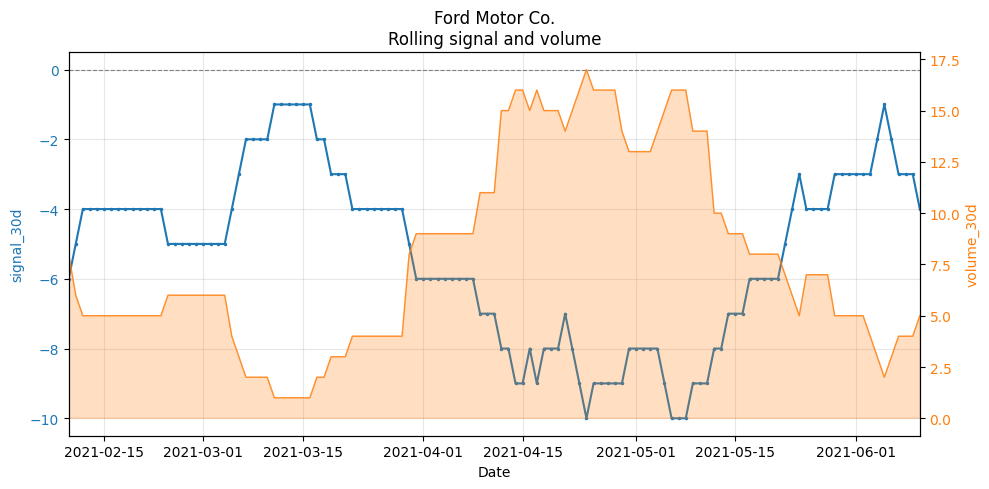

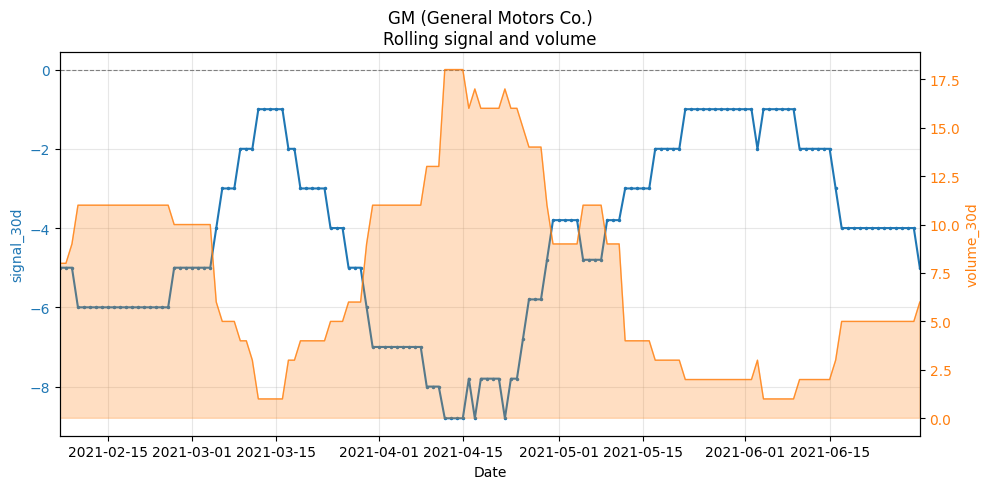

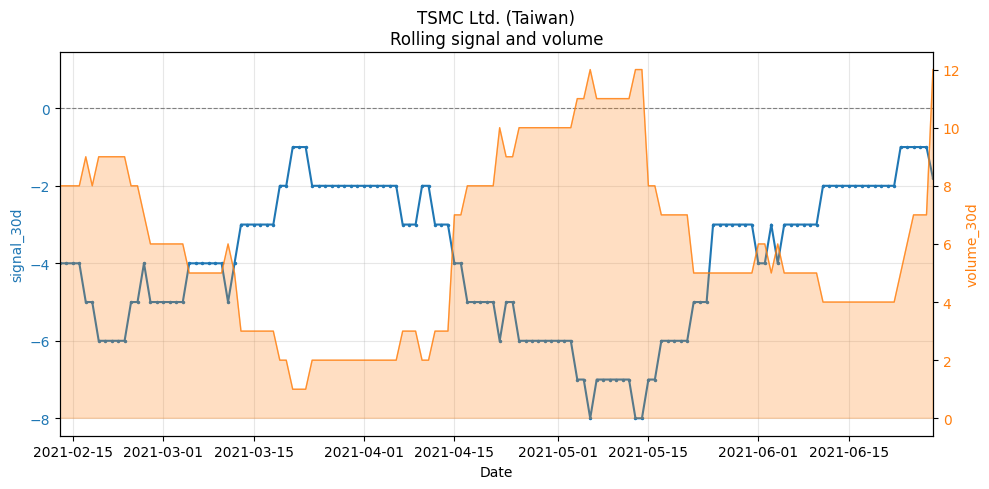

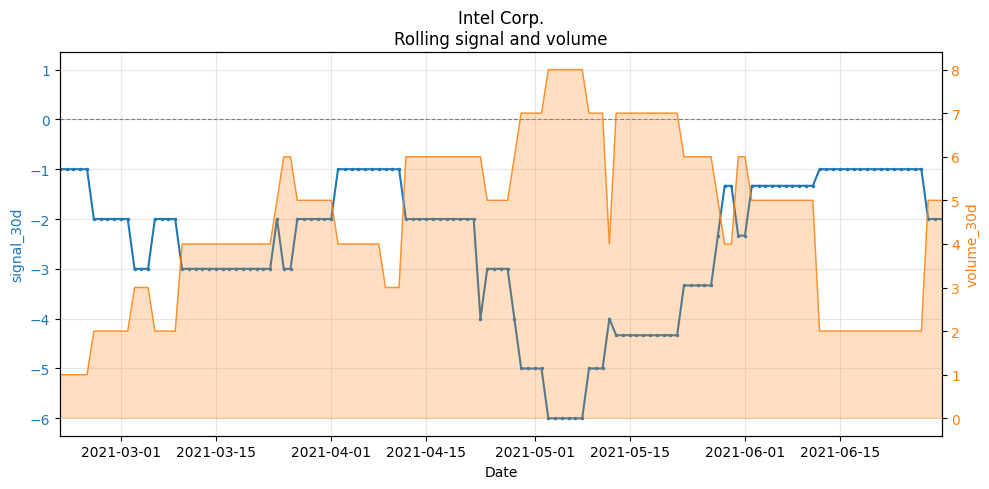

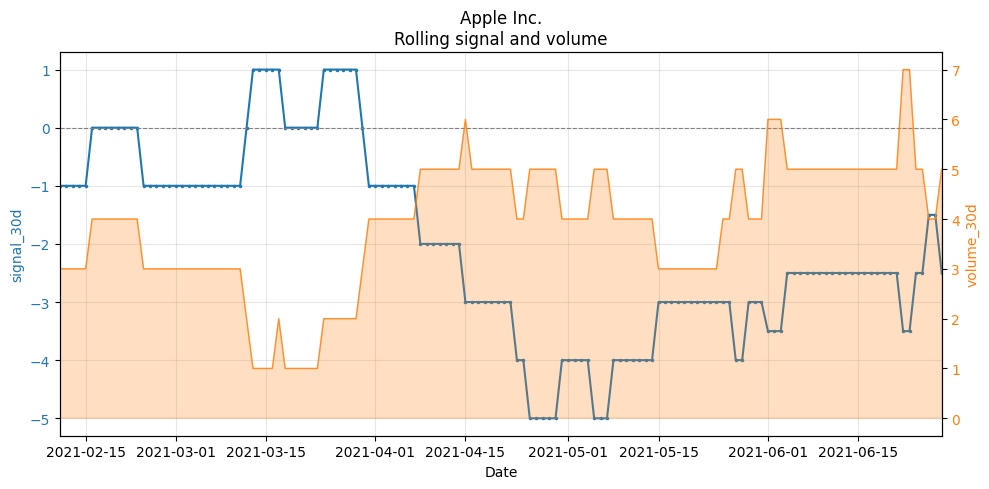

In [44]:
# Plot rolling signal for top 5 companies by volume
plot_top_entities_rolling_signal(
    df_rolling_signal,
    entity_col="entity_name",
    date_col="date_nyse_1530",
    signal_col="signal_30d",  # with the relative padding from window
    top_n=5,
)



In [45]:
# Save DF with rp_entity_id included
entity_id_map = (
    df_with_labels[["entity_name", "entity_id"]]
    .dropna(subset=["entity_name", "entity_id"])
    .drop_duplicates(subset=["entity_name"])
    .set_index("entity_name")["entity_id"]
)

df_rolling_signal_export = df_rolling_signal.copy()
if "rp_entity_id" not in df_rolling_signal_export.columns:
    df_rolling_signal_export["rp_entity_id"] = df_rolling_signal_export["entity_name"].map(entity_id_map)

# Put rp_entity_id near the entity name for easier downstream use
desired_order = ["entity_name", "rp_entity_id"] + [
    col for col in df_rolling_signal_export.columns if col not in {"entity_name", "rp_entity_id"}
]
df_rolling_signal_export = df_rolling_signal_export[desired_order]

df_rolling_signal_export.to_csv("df_rolling_signal.csv", index=False)


## Summary

1. **Advanced (LLM-verified):**
   - stricter, higher accuracy/precision, lower recall.

For robust research practice:
- validate timing assumptions (`doc_timestamp` -> `date_nyse_1530`),
- test signal behavior across themes and market regimes,
- treat in-sample performance as a **sanity check**, not proof of persistent alpha.

Recommended next steps:
- run robustness tests across alternate themes and windows,
- evaluate implementation frictions before any live deployment.

